---
title: Data Transformation Techniques
description: A comprehensive guide to handling skewed data using Function Transformers
  (Log, Reciprocal, Square, Square Root) and Power Transformers (Box-Cox, Yeo-Johnson)
  to normalize feature distributions for machine learning models.
author: Md Muztahid Hassan
date: '2026-05-30 17:10:06'
toc: true
execute:
  warning: false
  echo: true
order: 10
---


## Handling Skewed Data

There are some kinds of data that does not follow the normal distribution. Some are right skewed, some are left skewed. If we want to use such data for linear models like linear regression, logistic regression, etc., the models may not perform well. To handle skewed data, we can apply different transformations. This transformation techniques can help to normalize the data and make it more suitable for linear models. Here are some common transformation techniques for handling skewed data:

1. Log Transformation
2. Reciprocal Transformation
3. Square Transformation
4. Square Root Transformation

| Log T | Reciprocal | sq ($n^2$) | sqrt $\sqrt{n}$ |
| --- | --- | --- | --- |
| $\log(n)$ | $1/n$ | $n^2$ | $\sqrt{n}$ |

When we will apply these transformations, we will use the `FunctionTransformer` from the `sklearn.preprocessing` module. 

There are some other transformation techniques which are known as power transformation techniques. They are:
1. Box-Cox Transformation
2. Yeo-Johnson Transformation

These are in the `PowerTransformer` class of the `sklearn.preprocessing` module.

## Function Transformer

### 1. Log Transformation

**When we will use it?** 
- When the data is right skewed (positively skewed).
- The data should not have zero or negative values.

We will use the `titanic` dataset. You can download the dataset from <a href='train.csv'>here</a>.

In [94]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

We will just use the `Age`, `Fare`, and `Survived` columns for keeping our tutorial simple. But during the work, you have use all the columns of the dataset.

In [95]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [96]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

Here are some null values in the `Age` column. We will use the `SimpleImputer`, we learned earlier, to fill the null values with the mean of the column.

In [97]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
df['Age'] = imputer.fit_transform(df[['Age']])
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

Now we will seperate the features and target variable. The `Survived` column is our target variable and the `Age` and `Fare` columns are our features.

In [98]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Before applying the log transformation, we will see the ditribution of the columns.

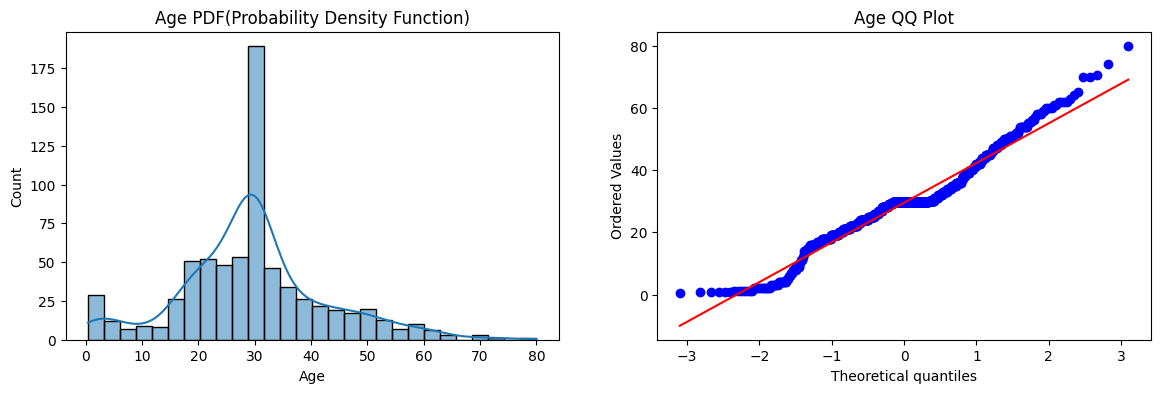

In [99]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF(Probability Density Function)')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

**Insights:**
- The distribution of the `Age` column, it is almost normally distributed. 
- The Q-Q plot also shows that the data points are almost on the straight line. So we will not apply transformation on the `Age` column.

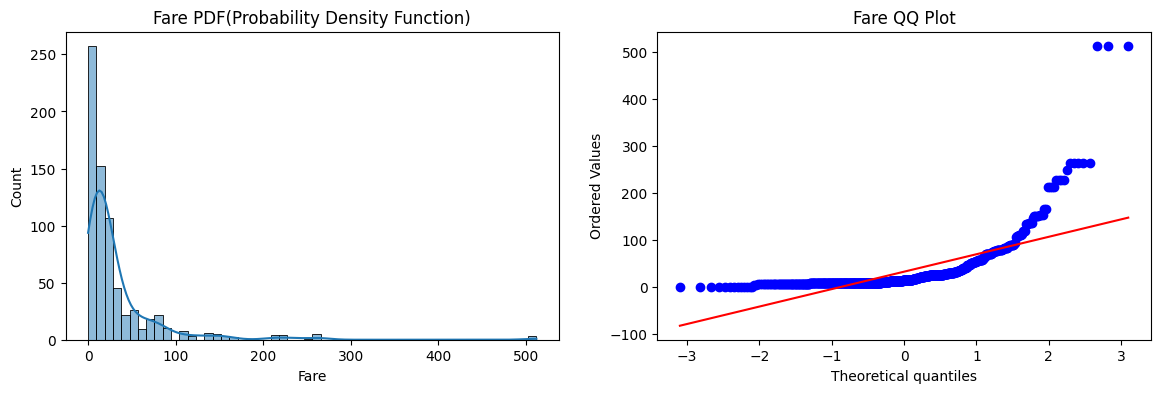

In [100]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF(Probability Density Function)')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

**Insights:**
- The `Fare` column is heavily right-skewed, as indicated by the PDF and QQ plot.
- The QQ plot for `Fare` shows that the data points deviate significantly from the straight line, confirming the presence of skewness.
- So, we need to apply transformation on the `Fare` column to make it more normally distributed.

The distribution is right skewed, so which transformation technique we will apply? We will apply the log transformation on the `Fare` column.

At first, we will train models and check accuracy without applying any transformation. Then we will apply the log transformation and check the accuracy again. Let's see if we can find any difference.

In [101]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [102]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred2))

Logistic Regression Accuracy: 0.6480446927374302
Decision Tree Accuracy: 0.6871508379888268


**Insights:**
- The accuracy of the non-linear model (Decision Tree) is higher than the linear model (Logistic Regression) before applying the log transformation. Because non-linear models can handle skewed data better than linear models.

Now we will apply the log transformation and check the accuracy again.

We will use the `FunctionTransformer` and mention the function as `np.log1p` because it can handle zero values. The `log1p` function computes `log(1 + x)`, which is useful for data that may contain zero values, as it avoids the issue of taking the logarithm of zero.

In [103]:
trf = FunctionTransformer(func=np.log1p)

In [104]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [105]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred2 = clf2.predict(X_test_transformed)

print("Logistic Regression Accuracy:",accuracy_score(y_test,y_pred))
print("Decision Tree Accuracy:",accuracy_score(y_test,y_pred2))

Logistic Regression Accuracy: 0.6815642458100558
Decision Tree Accuracy: 0.6927374301675978


**Insights:**
- The accuracy of the logistic regression model has improved after applying the log transformation.
- The accuracy of the decision tree model has not changed significantly even after applying the log transformation. This is because decision trees are not affected by the distribution of the data as much as linear models are.
- So, before using linear models, it is always a good practice to check the distribution of the data and apply appropriate transformations if needed.

Now we will apply Cross-Validation and check if the accuracy is consistent across different folds.

In [106]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("Cross-Validation Accuracy for Logistic Regression:", np.mean(cross_val_score(clf, X_transformed, y, cv=10)))
print("Cross-Validation Accuracy for Decision Tree:", np.mean(cross_val_score(clf2, X_transformed, y, cv=10)))

Cross-Validation Accuracy for Logistic Regression: 0.678027465667915
Cross-Validation Accuracy for Decision Tree: 0.6577028714107366


Now we will see in the graphical way how the log transformation has changed the distribution of the `Fare` column.

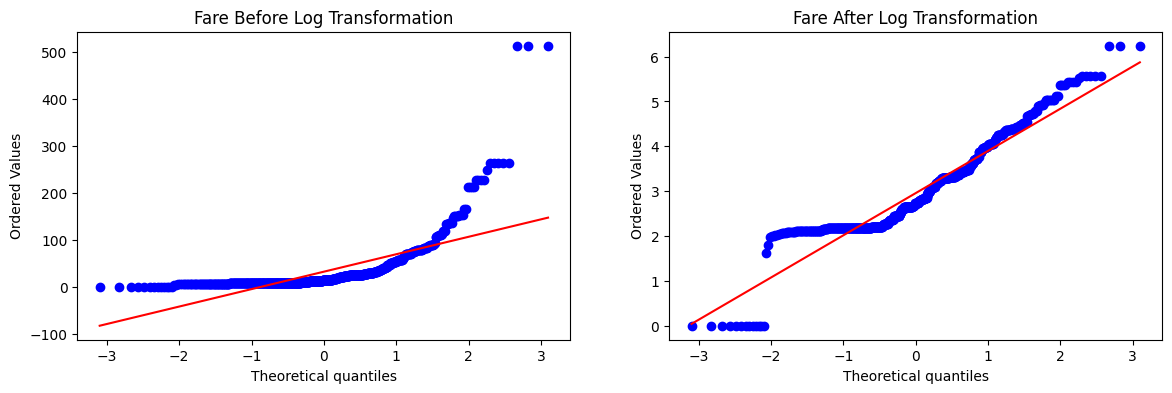

In [107]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log Transformation')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log Transformation')

plt.show()

**Insights:**
- After applying the log transformation, the distribution of the `Fare` column has aligned more with the straight line in the Q-Q plot, indicating that the data is now more normally distributed.

Now we will see the Q-Q plot of the `Age` column before and after applying the log transformation. 

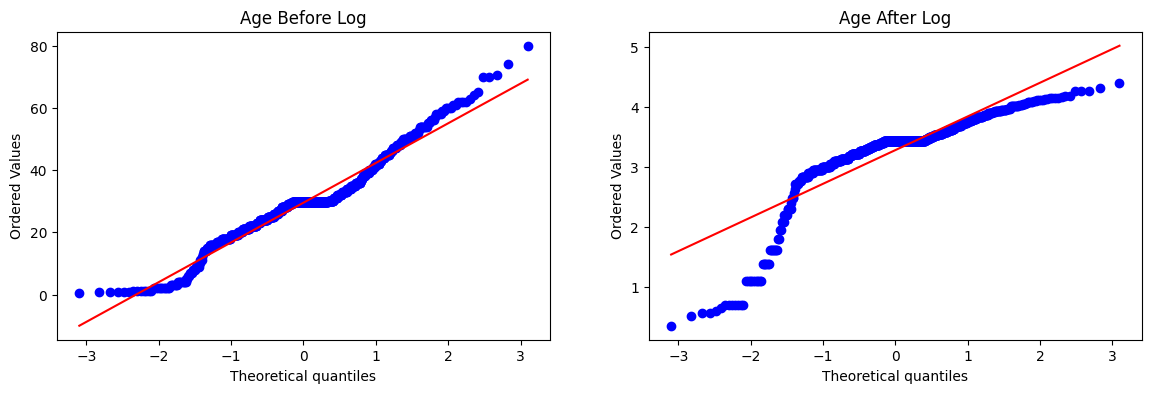

In [108]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

**Insights:**
- Why the Q-Q plot of the `Age` column is deviated from the straight line after applying the log transformation? Because the `Age` column is almost normally distributed before applying the log transformation. So, when we apply the log transformation, it distorts the distribution of the `Age` column and makes it less normally distributed. This is why we should not apply transformation on the `Age` column.

Now we will just apply the log transformation on the `Fare` column but not on the `Age` column and check the accuracy again. We can use the `ColumnTransformer` to apply the log transformation only on the `Fare` column.

In [109]:
trf = ColumnTransformer(
    transformers=[
        ('log_fare', FunctionTransformer(func=np.log1p), ['Fare'])
    ], remainder='passthrough'
)

X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [110]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred_lr = clf.predict(X_test_transformed)
y_pred_dt = clf2.predict(X_test_transformed)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 0.6703910614525139
Decision Tree Accuracy: 0.6815642458100558


We will again use cross-validation to check the accuracy.

In [111]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6566167290886391


The accuracy score didn't change that much. But we will see the Q-Q plot of the `Age` column.

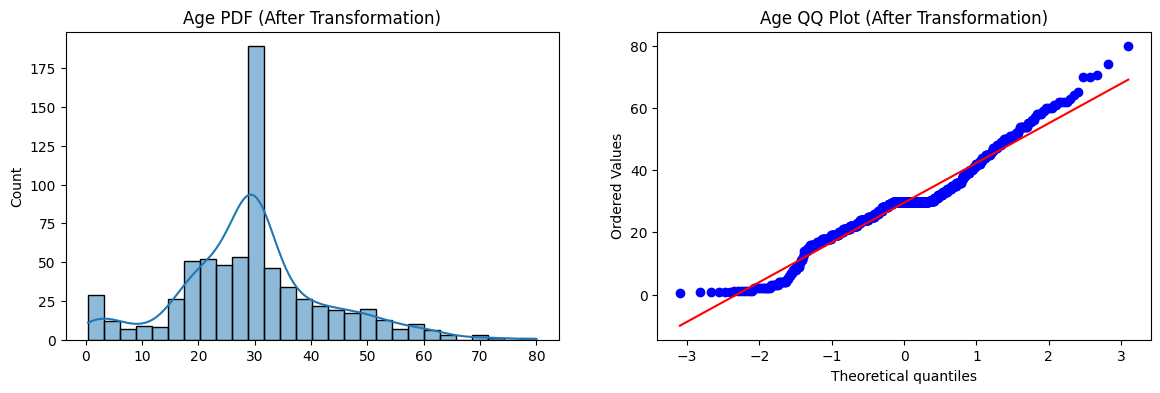

In [112]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train_transformed[:,1], kde=True)
plt.title('Age PDF (After Transformation)')

plt.subplot(122)
stats.probplot(X_train_transformed[:, 1], dist="norm", plot=plt)
plt.title('Age QQ Plot (After Transformation)')

plt.show()

This isn't changed as we didn't apply the log transformation on the `Age` column. 

Now we will apply other transformation techniques. At first, we will create a generic function which will take the transformation technique as an argument and apply that transformation on the `Fare` column. Then we will check the accuracy of the models and see the Q-Q plot of the `Fare` column after applying the transformation.

In [113]:
def apply_transformation(transformation):
    X = df.drop('Survived', axis=1)
    y = df['Survived']

    trf = ColumnTransformer(
        transformers = [
            ('log_fare', FunctionTransformer(func=transformation), ['Fare'])
        ], remainder='passthrough'
    )

    X_transformed = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy", np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_transformed[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Now we will apply the transformation techniques one by one.

Accuracy 0.6712609238451936


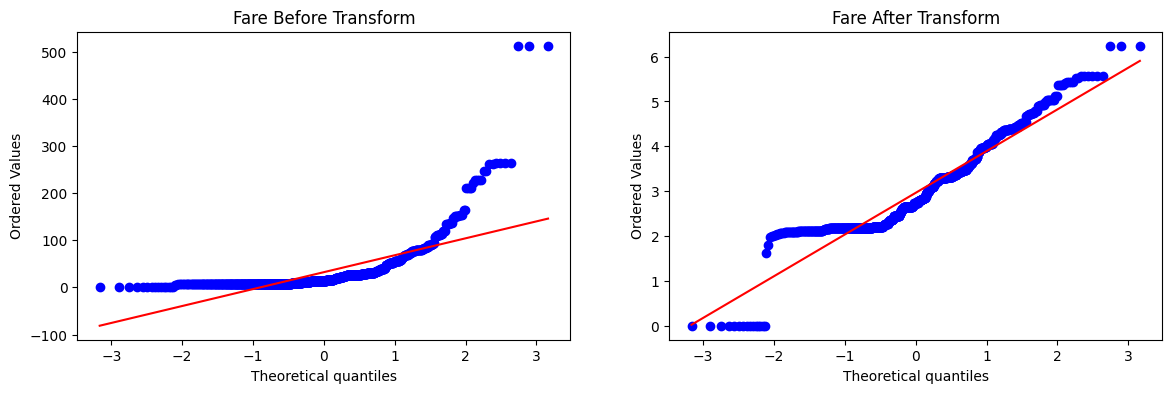

In [114]:
apply_transformation(np.log1p)

### 2. Reciprocal Transformation

Accuracy 0.61729088639201


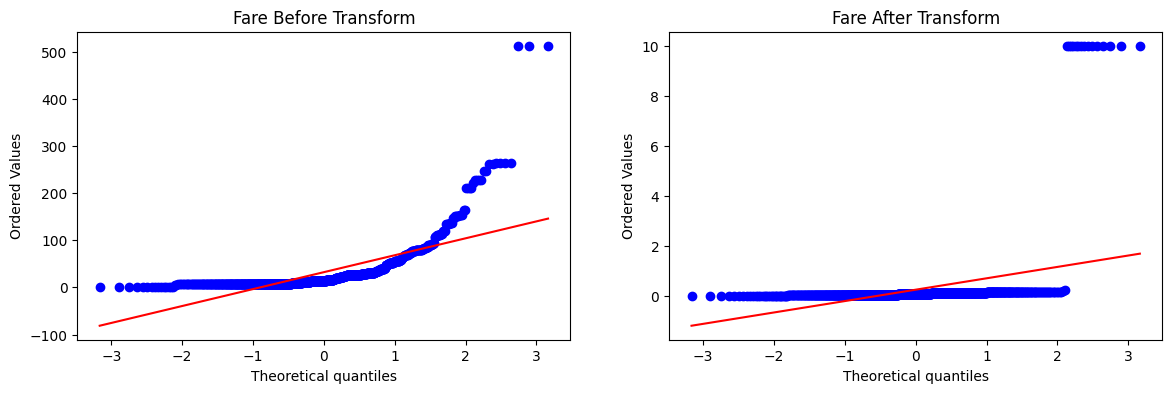

In [115]:
apply_transformation(lambda x: 1/(x+0.1))

**Insights:**
- The reciprocal transformation does not perform well on right-skewed data like the `Fare` column. The accuracy of the logistic regression model has decreased significantly after applying the reciprocal transformation.

### 3. Square Transformation

Accuracy 0.6431335830212235


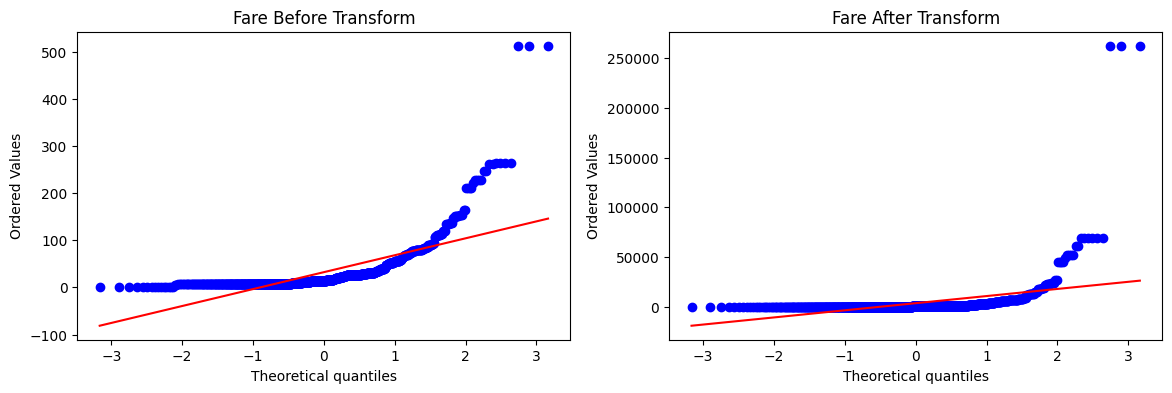

In [116]:
apply_transformation(np.square)

**Insights:**
- After applying the square transformation, the Q-Q plot of the `Fare` column is more aligned with the straight line, indicating that the data is now more normally distributed.
- The accuracy score is good but less than the log transformation. 

### 4. Square Root Transformation

Accuracy 0.6611485642946316


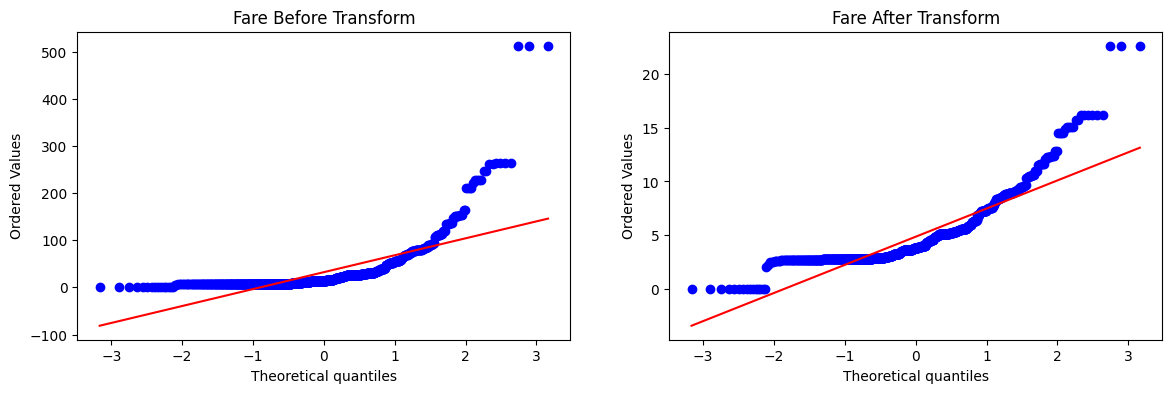

In [117]:
apply_transformation(lambda x: x**0.5)

**Insights:**
- The square transformation is almost like the square transformation. 
- So, the log transformation is the best transformation technique for handling right-skewed data like the `Fare` column in this case.

If the data was left skewed, the square transformation would have been the best transformation technique.

## Power Transformation Techniques

### 1. Box-Cox Transformation

The Box-Cox transformation is a power transformation technique used to stabilize variance and normalize data that does not follow a normal distribution. 

It is defined mathematically as:

$$y(\lambda) = \begin{cases} \frac{y^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\\\ \ln(y) & \text{if } \lambda = 0 \end{cases}$$

**Key Characteristics:**
- **Assumption:** The target variable $y$ must contain only strictly positive values ($y > 0$).
- **Parameter ($\lambda$):** The transformation searches for an optimal parameter $\lambda$ that maximizes the log-likelihood function to make the data as close to normally distributed as possible.
- **Implementation:** In `scikit-learn`, it can be applied using the `PowerTransformer` class with the `method='box-cox'` parameter.

In this transformation, we have the find the optimal value of $\lambda$ that will make the data as close to normally distributed as possible.

In [118]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

We will use `concrete` dataset for this transformation. You can download the dataset from <a href='concrete_data.csv'>here</a>.

In [119]:
df = pd.read_csv('concrete_data.csv')
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [120]:
df.shape

(1030, 9)

In [121]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [122]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


Here `Strength` is our target variable.

In [123]:
X = df.drop('Strength', axis=1)
y = df['Strength']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.6275531792314848

> Note: Here the target variable `Strength` contains continuous values. So, we will use the r2 score to evaluate the performance of the models instead of accuracy score(because accuracy score is used for classification problems, not for regression problems).

Now we will apply cross-validation and check if the r2 score of the models is consistent across different folds.

In [124]:
lr = LinearRegression()
np.mean(cross_val_score(lr,X,y,scoring='r2',cv=10))

np.float64(0.27820729160873753)

There is a significant performance drop after cross-validation. So, we should not rely on the r2 score of the models without applying cross-validation. We should always apply cross-validation to check the performance of the models.

So, we will perform some EDA tasks to check how is the data.

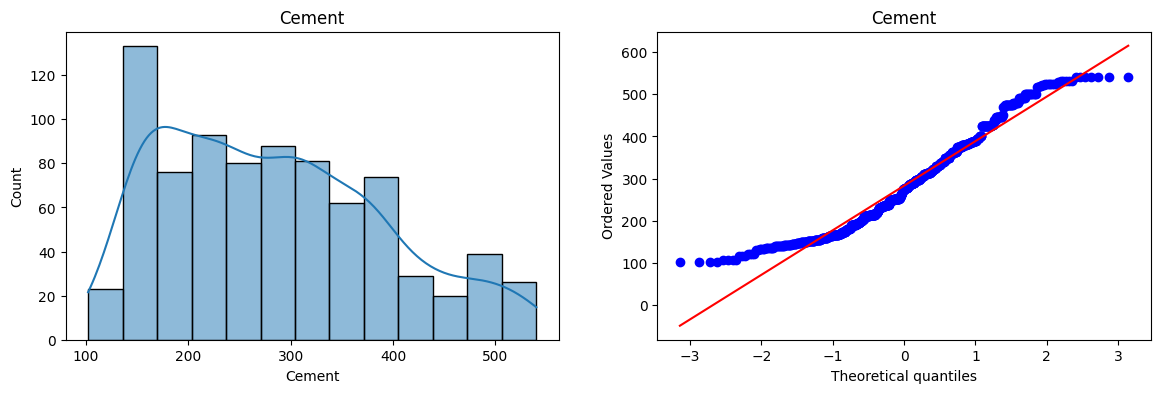

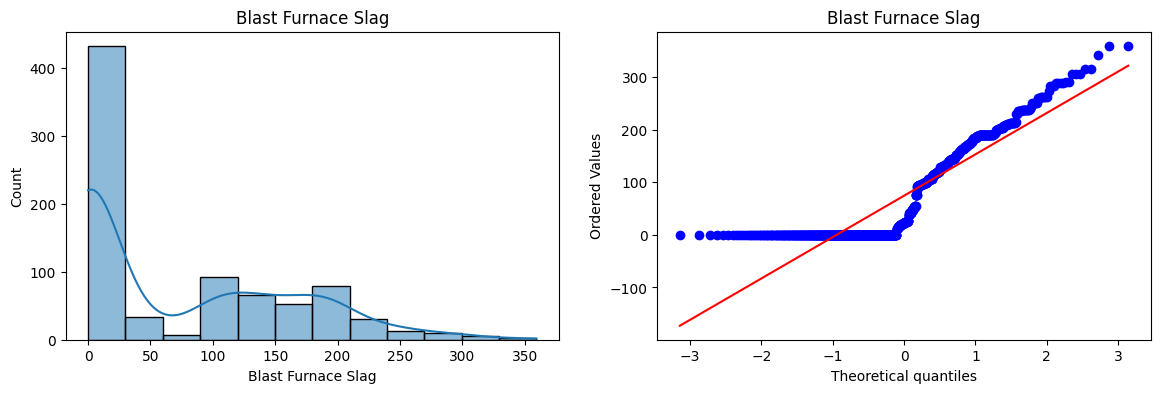

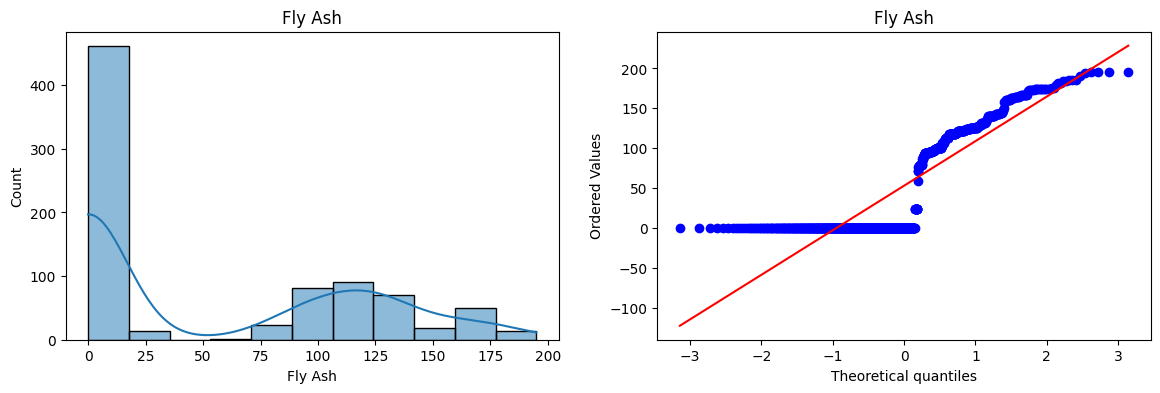

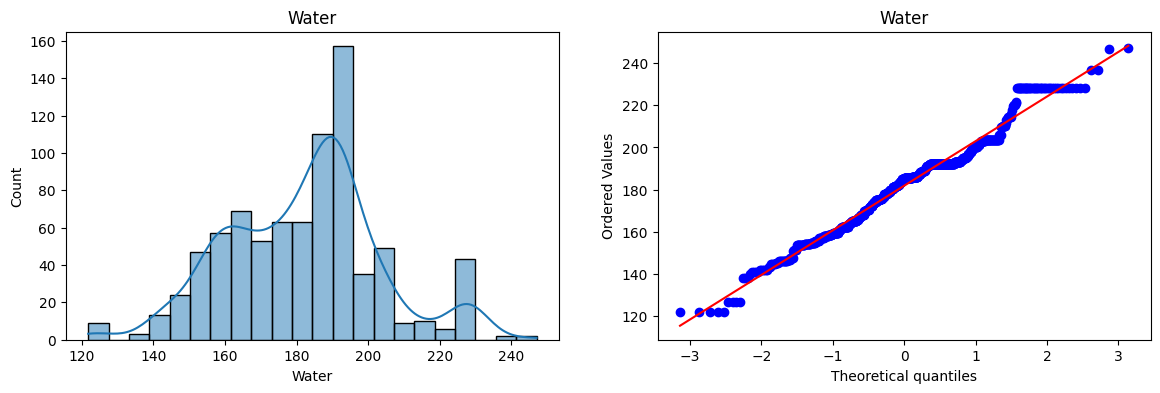

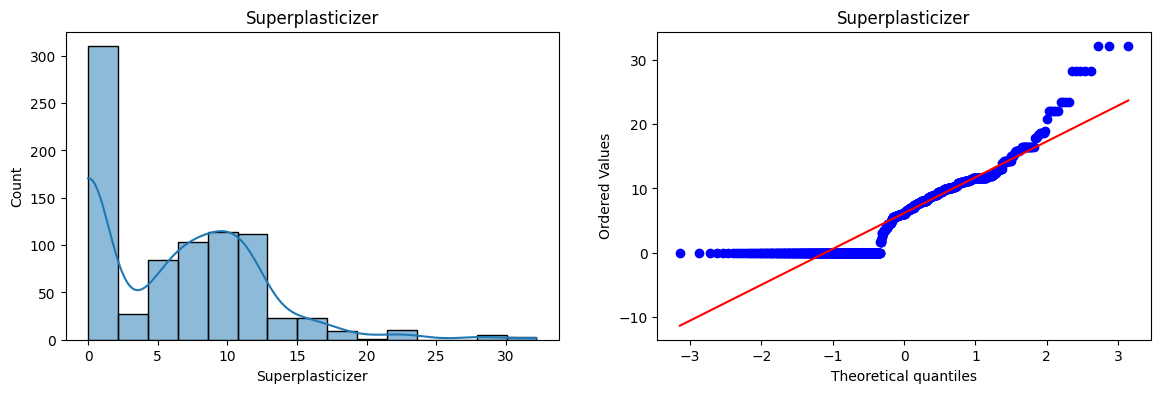

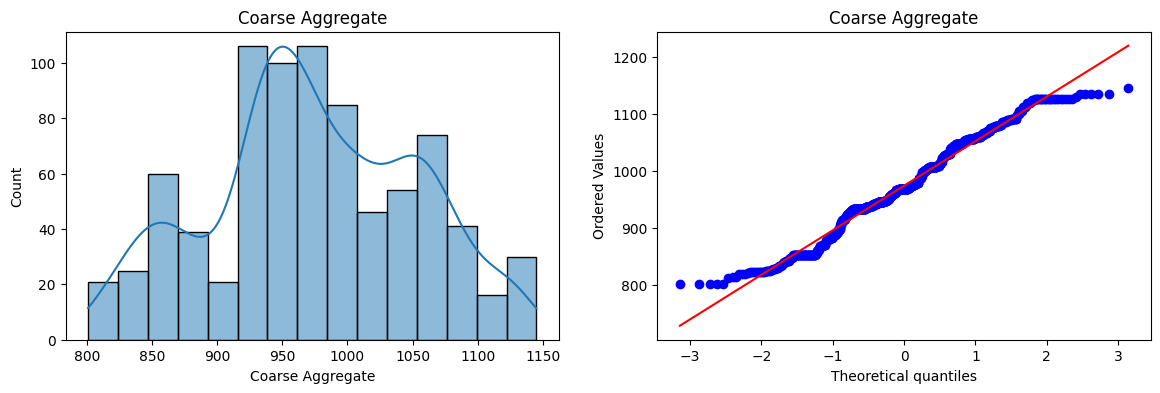

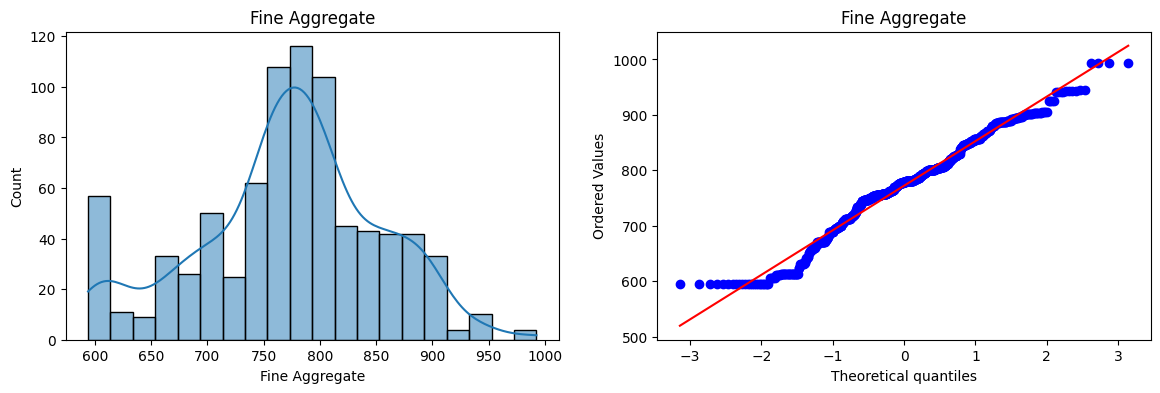

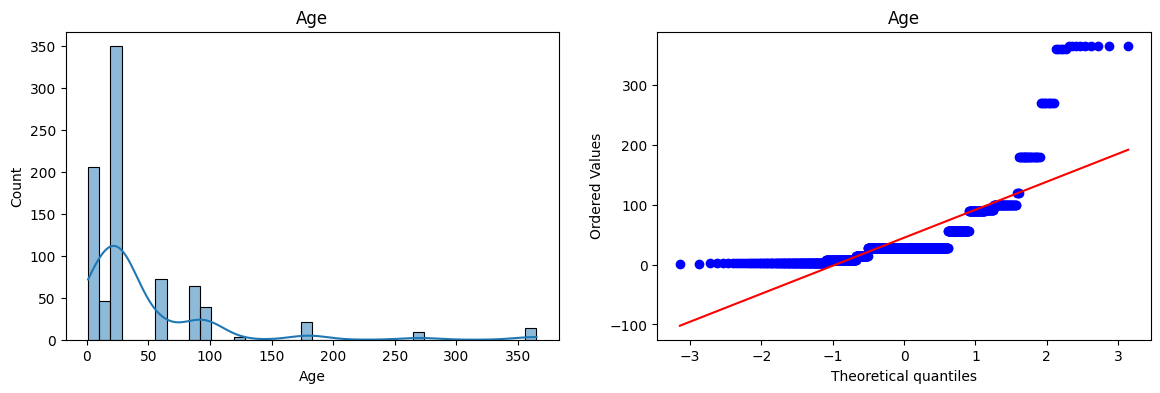

In [125]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

**Insights:**
- `Cement`, `Water`, `Corse_Aggregate`, and `Fine_Aggregate` columns are close to normal distribution.

In [126]:
# Applying Box-Cox Transform

pt = PowerTransformer(method='box-cox')
# Adding a small constant to avoid zero values in the data because Box-Cox transformation cannot be applied to zero or negative values.
X_train_transformed = pt.fit_transform(X_train+0.000001) 
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_}) # This is for the lambda parameter of each column

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


Now we will check the accuracy of the models after applying the Box-Cox transformation.

In [127]:
lr = LinearRegression()
lr.fit(X_train_transformed,y_train)
y_pred = lr.predict(X_test_transformed)
r2_score(y_test,y_pred)

0.8047825008078886

Look the accuracy score has improved significantly after applying the Box-Cox transformation. Now we will again apply cross-validation and check if the r2 score of the models is consistent across different folds.

In [128]:
pt = PowerTransformer(method='box-cox')

X_transformed = pt.fit_transform(X+0.000001)
lr = LinearRegression()
print("Cross-Validation R2 Score:", np.mean(cross_val_score(lr, X_transformed, y, scoring='r2', cv=10)))

Cross-Validation R2 Score: 0.6466764736678003


The cross-validation r2 score has also improved significantly after applying the Box-Cox transformation. 

Now we will see the distribution of the columns after applying the Box-Cox transformation.

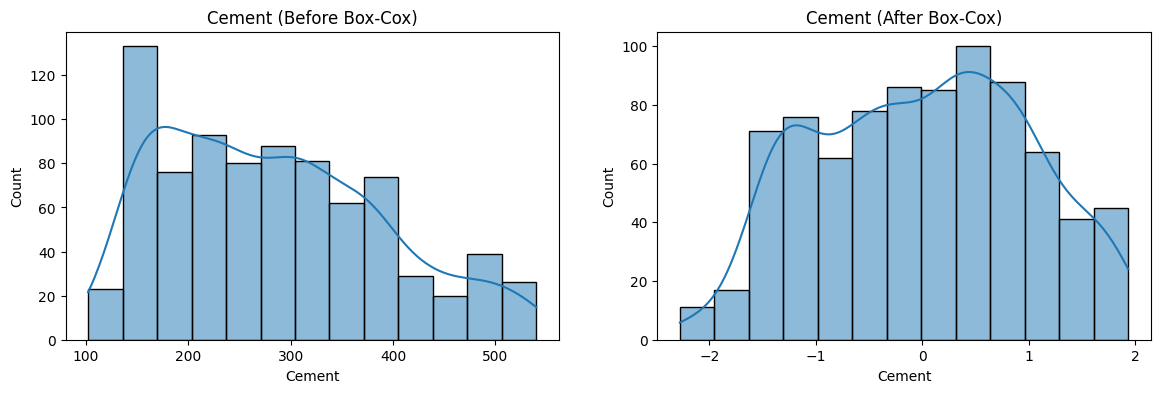

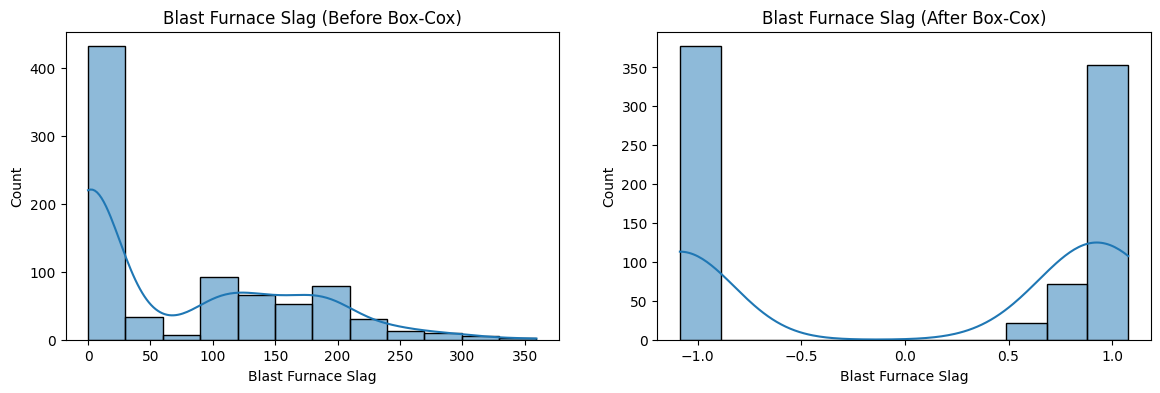

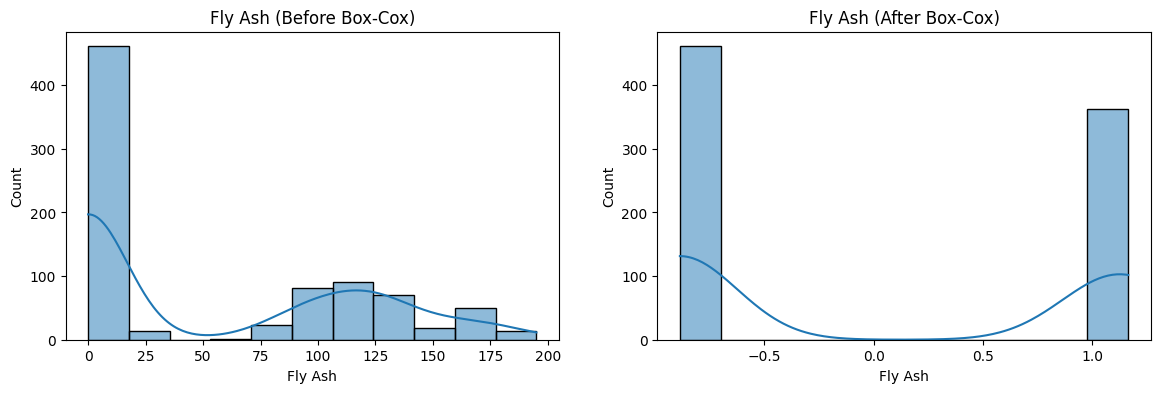

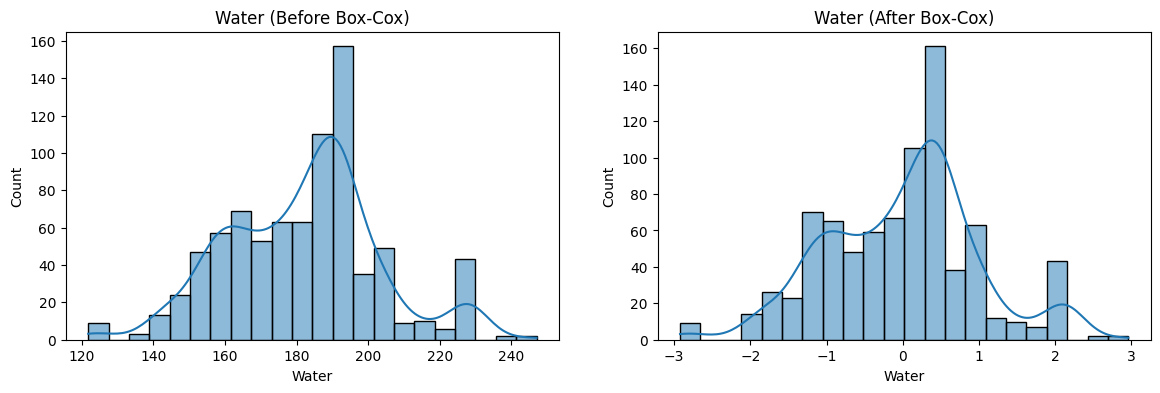

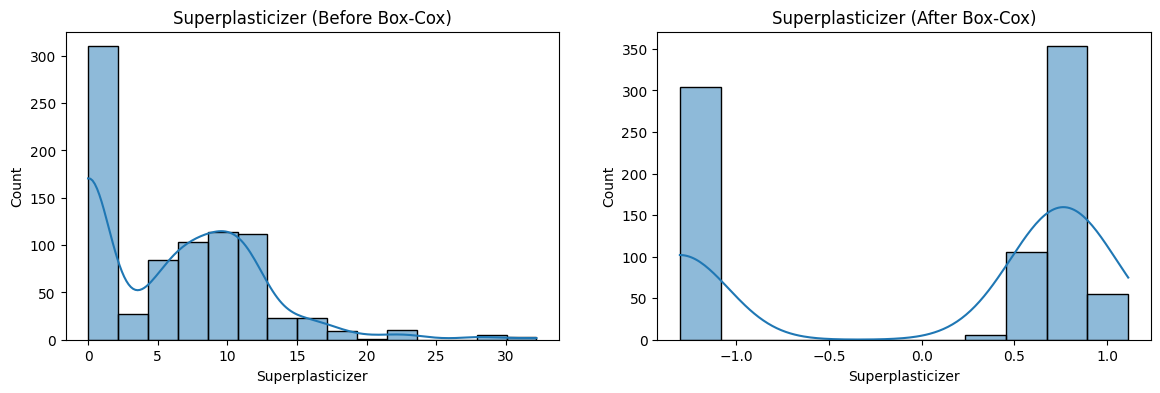

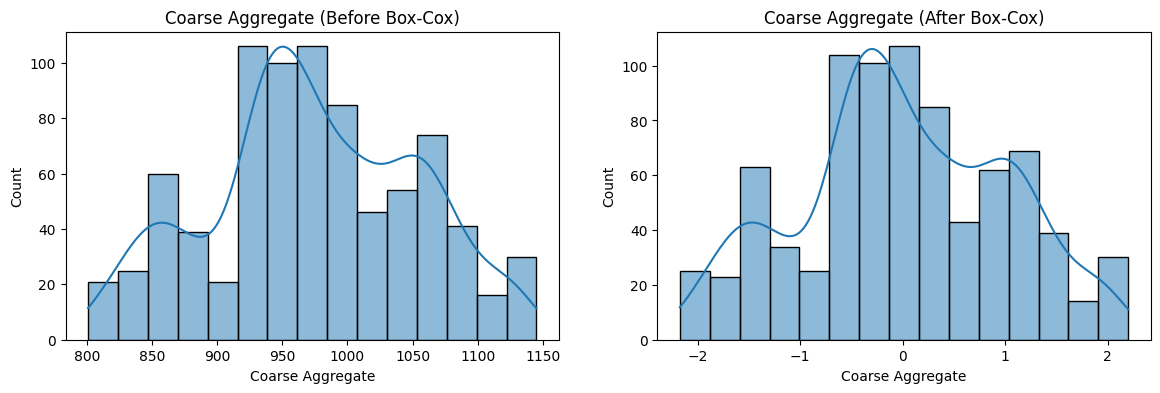

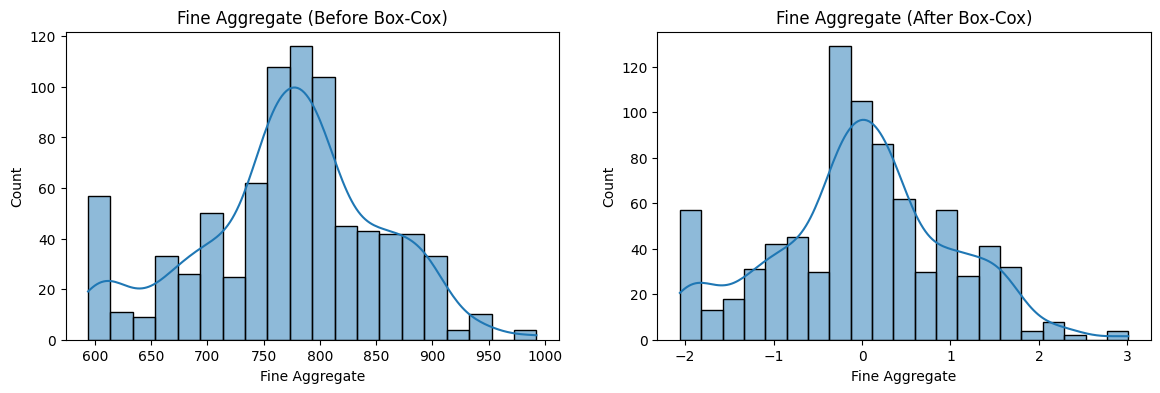

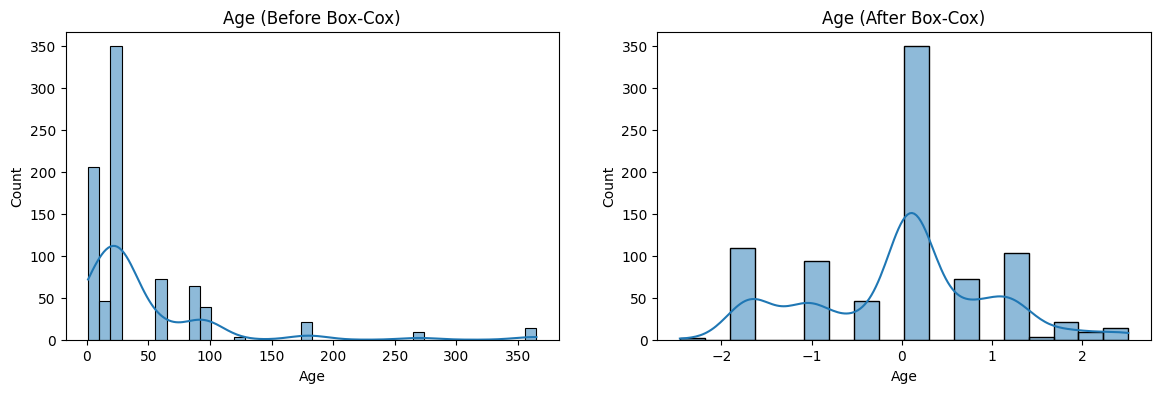

In [129]:
X_train_transformed = pd.DataFrame(X_train_transformed,columns=X_train.columns)

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(f"{col} (Before Box-Cox)")

    plt.subplot(122)
    sns.histplot(X_train_transformed[col], kde=True)
    plt.title(f"{col} (After Box-Cox)")

    plt.show()

### 2. Yeo-Johnson Transformation

The Yeo-Johnson transformation is a power transformation technique used to stabilize variance and make data more normally distributed. It is defined mathematically as:

$$y(\lambda) = \begin{cases} \frac{(y + 1)^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0, y \geq 0 \\\\ \ln(y + 1) & \text{if } \lambda = 0, y \geq 0 \\\\ -\frac{(-y + 1)^{2 - \lambda} - 1}{2 - \lambda} & \text{if } \lambda \neq 2, y < 0 \\\\ -\ln(-y + 1) & \text{if } \lambda = 2, y < 0 \end{cases}$$

**Why Yeo-Johnson is Broadly Used (Solving Box-Cox Drawbacks)**
- **Support for Zero and Negative Values:** The primary drawback of the **Box-Cox** transformation is that it requires the target variable to be strictly positive ($y > 0$). If the dataset contains zeros or negative numbers, Box-Cox cannot be applied without shifting the data. 
- **Universal Applicability:** The **Yeo-Johnson** transformation solves this limitation by allowing $y$ to be positive, zero, or negative. This makes it highly versatile and broadly applicable to any numerical feature without requiring manual data-shifting prep work.
- **Implementation:** In `scikit-learn`, it can be applied using the `PowerTransformer` class with the `method='yeo-johnson'` parameter (which is also the default method).


Now we will apply the Yeo-Johnson transformation.

In [130]:
pt = PowerTransformer() # By default, it uses the Yeo-Johnson method
X_train_transformed = pt.fit_transform(X_train)
X_test_transformed = pt.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed,y_train)
y_pred = lr.predict(X_test_transformed)
print("R2 Score after Yeo-Johnson Transformation:", r2_score(y_test,y_pred))
pd.DataFrame({'cols':X_train.columns,'yeo_johnson_lambdas':pt.lambdas_})

R2 Score after Yeo-Johnson Transformation: 0.8161906511066099


,cols,yeo_johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


Now we will apply the cross-validation and check the r2 score of the models.

In [131]:
pt = PowerTransformer()
X_transformed = pt.fit_transform(X)
lr = LinearRegression()
print("Cross-Validation R2 Score after Yeo-Johnson:", np.mean(cross_val_score(lr, X_transformed, y, scoring='r2', cv=10)))

Cross-Validation R2 Score after Yeo-Johnson: 0.6586548619389643


Here is also a significant improvement in the r2 score after applying the Yeo-Johnson transformation. Let's see the distribution of the columns after applying the Yeo-Johnson transformation.

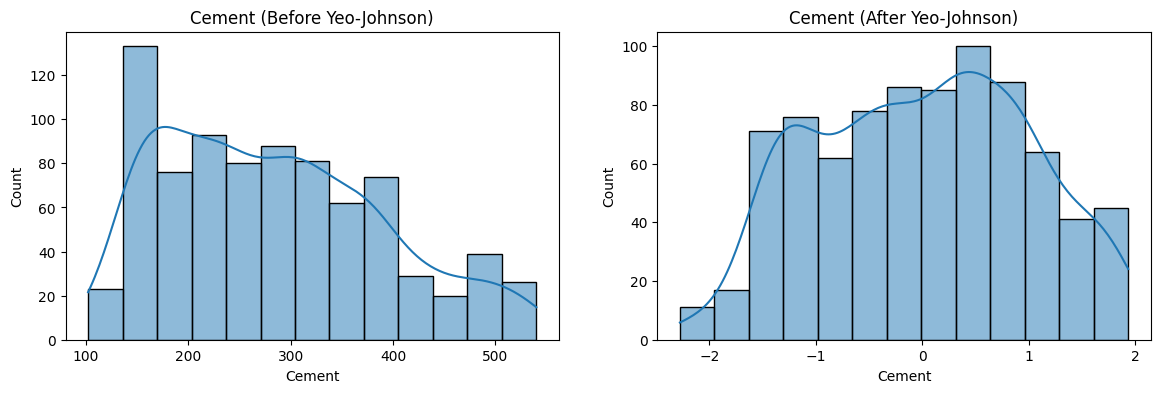

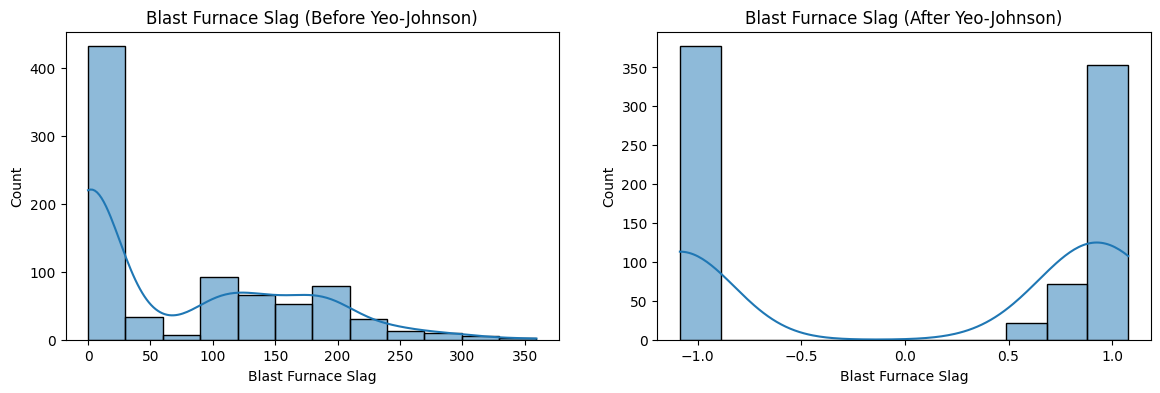

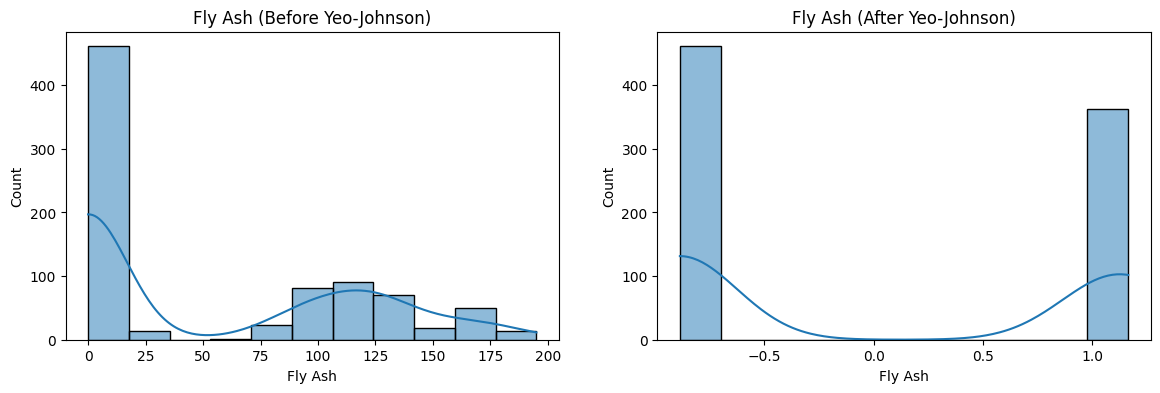

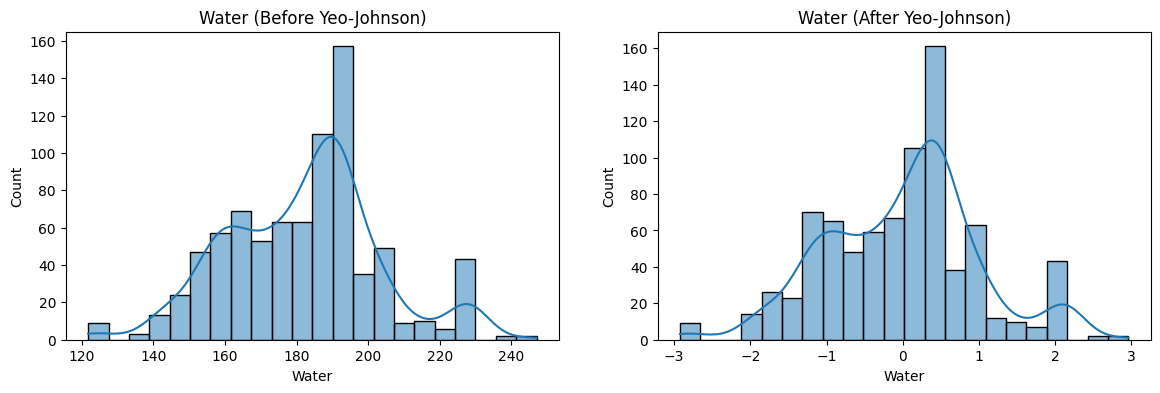

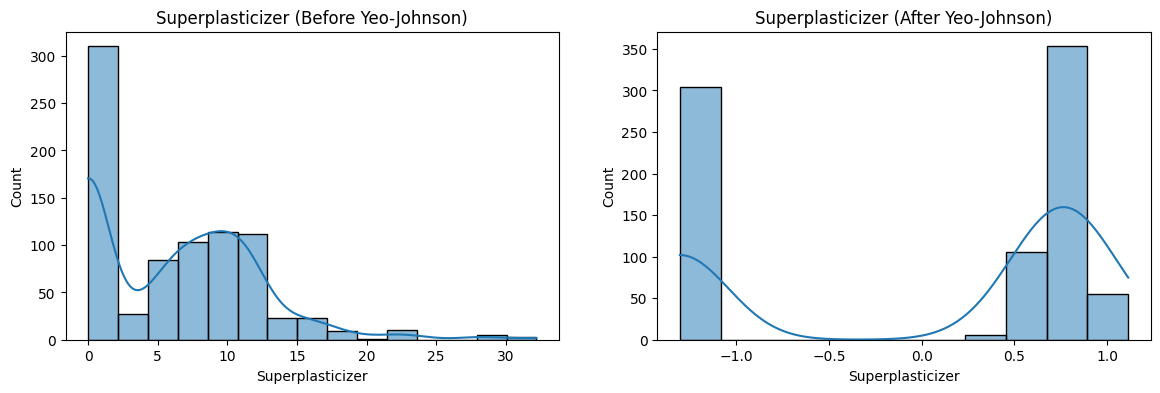

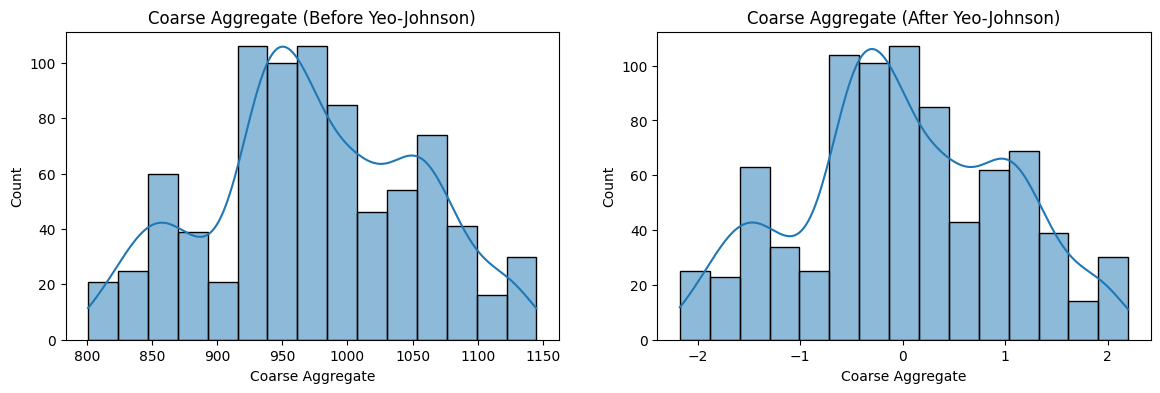

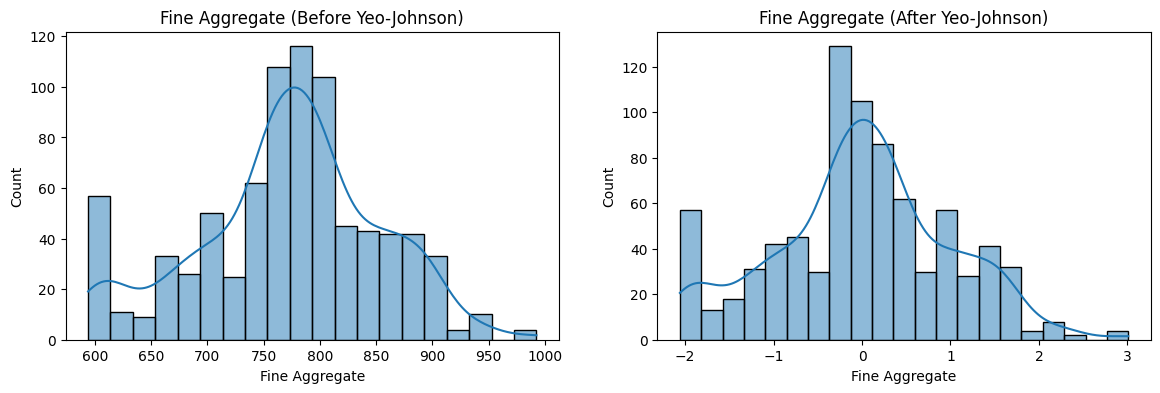

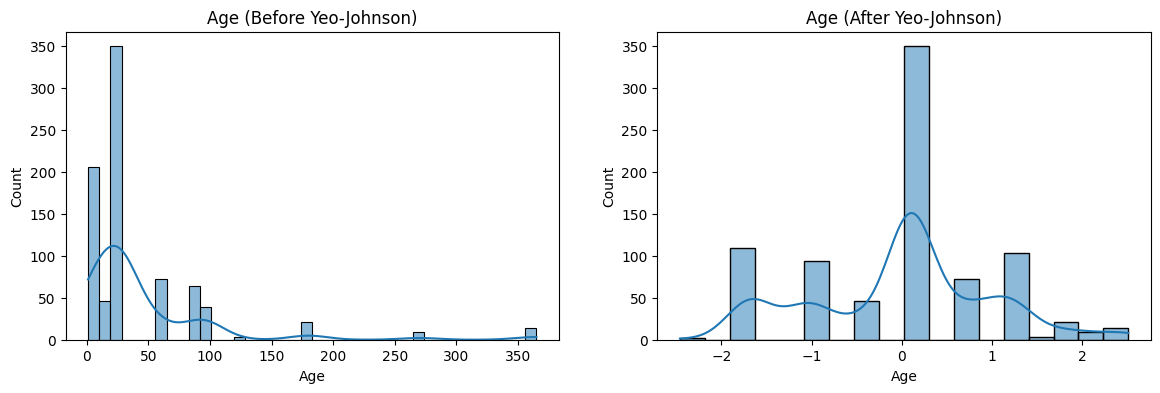

In [134]:
X_train_transformed = pd.DataFrame(X_train_transformed,columns=X_train.columns)

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(f"{col} (Before Yeo-Johnson)")

    plt.subplot(122)
    sns.histplot(X_train_transformed[col], kde=True)
    plt.title(f"{col} (After Yeo-Johnson)")

    plt.show()

Side by Side lambda values of the Box-Cox and Yeo-Johnson transformations:

In [133]:
pt = PowerTransformer(method='box-cox')
X_train_transformed = pt.fit_transform(X_train+0.000001)

pt1 = PowerTransformer(method='yeo-johnson')
X_train_transformed1 = pt1.fit_transform(X_train)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement,0.177025,0.174348
1,Blast Furnace Slag,0.025093,0.015715
2,Fly Ash,-0.038970,-0.161447
3,Water,0.772682,0.771307
4,Superplasticizer,0.098811,0.253935
5,Coarse Aggregate,1.129813,1.130050
6,Fine Aggregate,1.782018,1.783100
7,Age,0.066631,0.019885
